# AutoGluon-TimeSeries 


## 1. Synthetische Daten erzeugen

In [ ]:
%pip install autogluon

In [11]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_buildings = 10
n_days = 90
freq_h = 1  # stündlich
timestamps = pd.date_range("2024-01-01", periods=n_days * 24, freq="h")

rows = []
for bid in range(1, n_buildings + 1):
    # Gebäudespezifische Parameter
    base_load = np.random.uniform(20, 60)        # kWh Grundlast
    daily_amp = np.random.uniform(10, 30)         # Tagesamplitude
    weekly_amp = np.random.uniform(3, 10)          # Wochenamplitude
    noise_std = np.random.uniform(2, 8)            # Rauschen
    trend_slope = np.random.uniform(-0.002, 0.005) # leichter Trend

    t = np.arange(len(timestamps))
    hour_of_day = timestamps.hour
    day_of_week = timestamps.dayofweek

    # Tagesprofil: Peak morgens (8-9) und abends (18-20)
    daily_pattern = daily_amp * (
        0.6 * np.exp(-0.5 * ((hour_of_day - 9) / 2.5) ** 2) +
        0.8 * np.exp(-0.5 * ((hour_of_day - 19) / 2.0) ** 2)
    )

    # Wochenprofil: Wochenende niedriger
    weekly_pattern = weekly_amp * np.where(day_of_week >= 5, -1, 0.4)

    # Zusammensetzen
    consumption = (
        base_load
        + trend_slope * t
        + daily_pattern
        + weekly_pattern
        + noise_std * np.random.randn(len(timestamps))
    )
    consumption = np.maximum(consumption, 0)  # kein negativer Verbrauch

    for ts, val in zip(timestamps, consumption):
        rows.append({"building_id": f"B{bid:03d}", "timestamp": ts, "consumption": round(val, 2)})

df = pd.DataFrame(rows)
df.to_csv("energy_data.csv", index=False)
print(f"Datensatz: {len(df):,} Zeilen, {n_buildings} Gebäude, {n_days} Tage")
df.head(10)

Datensatz: 21,600 Zeilen, 10 Gebäude, 90 Tage


,building_id,timestamp,consumption
0,B001,2024-01-01 00:00:00,39.82
1,B001,2024-01-01 01:00:00,43.99
2,B001,2024-01-01 02:00:00,35.33
3,B001,2024-01-01 03:00:00,36.27
4,B001,2024-01-01 04:00:00,37.39
5,B001,2024-01-01 05:00:00,37.90
6,B001,2024-01-01 06:00:00,32.09
7,B001,2024-01-01 07:00:00,56.18
8,B001,2024-01-01 08:00:00,58.86
9,B001,2024-01-01 09:00:00,47.11


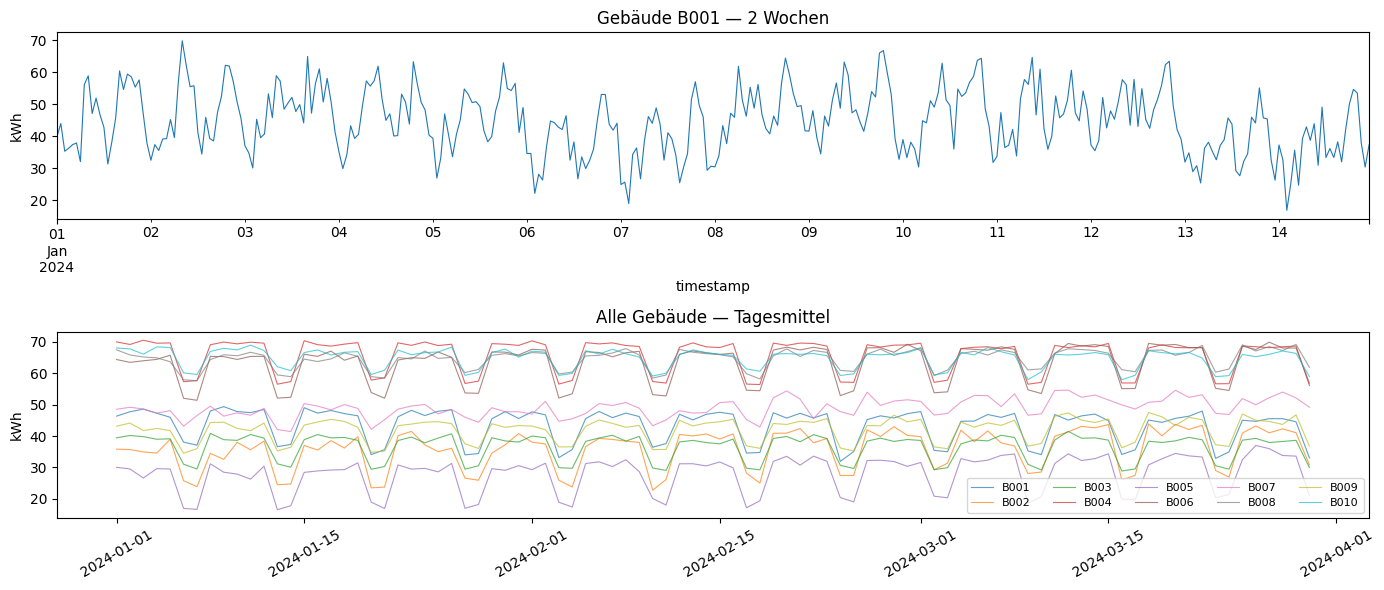

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Gebäude 1: erste 2 Wochen
b1 = df[df["building_id"] == "B001"].copy()
b1["timestamp"] = pd.to_datetime(b1["timestamp"])
b1 = b1.set_index("timestamp")["consumption"]
b1.iloc[:14*24].plot(ax=axes[0], lw=0.8)
axes[0].set_title("Gebäude B001 — 2 Wochen")
axes[0].set_ylabel("kWh")

# Alle Gebäude: Tagesmittel
daily = df.copy()
daily["timestamp"] = pd.to_datetime(daily["timestamp"])
daily["date"] = daily["timestamp"].dt.date
for bid in df["building_id"].unique():
    sub = daily[daily["building_id"] == bid].groupby("date")["consumption"].mean()
    axes[1].plot(sub.index, sub.values, lw=0.8, alpha=0.7, label=bid)
axes[1].set_title("Alle Gebäude — Tagesmittel")
axes[1].set_ylabel("kWh")
axes[1].legend(ncol=5, fontsize=8)
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

## 2. AutoGluon-TimeSeries

In [4]:
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

# Daten laden
df = pd.read_csv("energy_data.csv")
df = df.rename(columns={"consumption": "target"})
data = TimeSeriesDataFrame.from_data_frame(
    df, id_column="building_id",
    timestamp_column="timestamp"
)
train, test = data.train_test_split(prediction_length=24)
print(f"Train: {len(train):,} Zeilen | Test: {len(test):,} Zeilen")

/Users/grigo/gits/seminars/gfu/ML_Zeitreihen/src_live/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 21,360 Zeilen | Test: 21,600 Zeilen


In [13]:
# AutoML
predictor = TimeSeriesPredictor(
    prediction_length=24, eval_metric="MAE", path="autogluon_ts"
)
predictor.fit(train, time_limit=600, presets="high_quality")

Beginning AutoGluon training... Time limit = 600s
AutoGluon will save models to '/Users/grigo/gits/seminars/gfu/ML_Zeitreihen/src_live/autogluon_ts'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.5.0: Mon Apr 27 20:39:42 PDT 2026; root:xnu-12377.121.6~2/RELEASE_ARM64_T6031
CPU Count:          16
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       12.83 GB / 48.00 GB (26.7%)
Disk Space Avail:   75.78 GB / 926.35 GB (8.2%)
Setting presets to: high_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MAE,
 'hyperparameters': 'default',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 24,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'ran

In [14]:
# Leaderboard
predictor.leaderboard(test)

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,Chronos2SmallFineTuned,-4.317411,-4.152421,0.964326,0.294473,81.359584,5
1,ChronosWithRegressor[bolt_small],-4.509718,-4.063678,1.746164,52.490657,0.011144,7
2,DirectTabular,-4.513943,-4.165219,0.041529,0.037187,3.937542,3
3,DeepAR,-4.593630,-4.209882,0.174436,0.171512,115.162773,9
4,TemporalFusionTransformer,-4.960528,-4.080499,0.036455,0.013540,109.784118,8
5,WeightedEnsemble,-4.985463,-4.000083,6.864223,57.809913,0.096563,10
6,RecursiveTabular,-4.985824,-4.619847,0.065340,0.043310,2.976733,2
7,DynamicOptimizedTheta,-9.720213,-4.324595,2.761271,2.714830,0.008511,4
8,AutoETS,-10.047719,-4.075450,2.276963,2.552284,0.008503,6
9,SeasonalNaive,-10.261875,-5.923333,2.479819,2.441926,0.011284,1


## 3. Prognose & Visualisierung

In [15]:
# predict() erzeugt Prognose für die nächsten prediction_length Schritte
# nach Ende der übergebenen Daten → train übergeben, nicht test
predictions = predictor.predict(train)
predictions.head()

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


mean        0.1        0.2        0.3  \
item_id timestamp                                                         
B001    2024-03-30 00:00:00  26.320195  18.508559  20.944393  22.636261   
        2024-03-30 01:00:00  24.799264  16.450881  19.077632  21.072032   
        2024-03-30 02:00:00  25.453103  16.503162  19.286894  21.556062   
        2024-03-30 03:00:00  26.396939  17.075168  19.857011  22.300257   
        2024-03-30 04:00:00  28.386002  18.566082  21.461864  24.119052   

                                   0.4        0.5        0.6        0.7  \
item_id timestamp                                                         
B001    2024-03-30 00:00:00  25.034615  26.320195  28.038232  30.031193   
        2024-03-30 01:00:00  23.358557  24.799264  26.580272  28.565898   
        2024-03-30 02:00:00  23.936271  25.453103  27.329287  29.406295   
        2024-03-30 03:00:00  24.696132  26.396939  28.386038  30.512390   
        2024-03-30 04:00:00  26.506680  28.386002  30.385287  32.549047   

                                   0.8        0.9  
item_id timestamp                                  
B001    2024-03-30 00:00:00  31.872382  35.152686  
        2024-03-30 01:00:00  30.616530  34.112520  
        2024-03-30 02:00:00  31.693920  35.357723  
        2024-03-30 03:00:00  33.019821  36.872040  
        2024-03-30 04:00:00  35.250766  39.310008

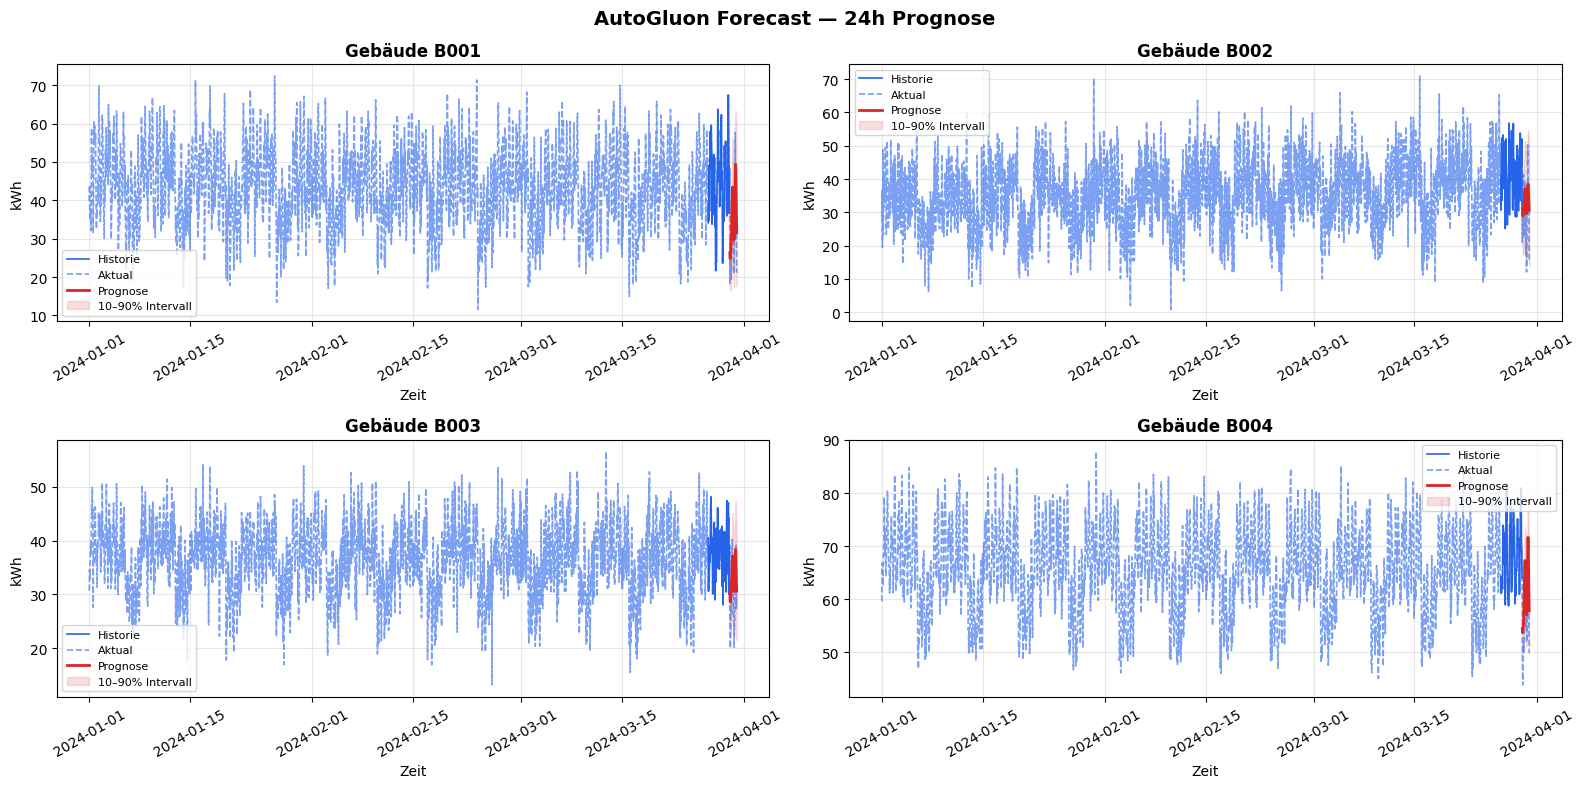

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for ax, bid in zip(axes.flat, ["B001", "B002", "B003", "B004"]):
    # Letzte 72h Trainings-Daten
    hist = train.loc[bid]["target"].iloc[-72:]

    # Aktualwerte (Test)
    actual = test.loc[bid]["target"]

    # Prognose — Index aus predictions verwenden
    pred = predictions.loc[bid]["mean"]

    ax.plot(hist.index, hist.values, color="#2563eb", lw=1.2, label="Historie")
    ax.plot(actual.index, actual.values, color="#2563eb", lw=1.2, ls="--", alpha=0.6, label="Aktual")
    ax.plot(pred.index, pred.values, color="#dc2626", lw=2, label="Prognose")

    # Konfidenzintervall
    if "0.1" in predictions.columns and "0.9" in predictions.columns:
        lo = predictions.loc[bid]["0.1"]
        hi = predictions.loc[bid]["0.9"]
        ax.fill_between(pred.index, lo.values, hi.values, alpha=0.15, color="#dc2626", label="10–90% Intervall")

    ax.set_title(f"Gebäude {bid}", fontweight="bold")
    ax.set_xlabel("Zeit")
    ax.set_ylabel("kWh")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("AutoGluon Forecast — 24h Prognose", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## 4. Metriken manuell berechnen

In [17]:
results = []

for bid in data.item_ids:
    actual = test.loc[bid]["target"].values[:24]
    pred = predictions.loc[bid]["mean"].values[:24]
    errors = actual - pred

    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors ** 2))
    mape = np.mean(np.abs(errors) / np.where(actual == 0, np.nan, actual)) * 100
    wape = np.sum(np.abs(errors)) / np.sum(np.abs(actual)) * 100
    forecast_bias = np.sum(errors) / np.sum(actual)

    # MASE: skaliert mit In-Sample naivem MAE
    train_vals = train.loc[bid]["target"].values
    naive_mae = np.mean(np.abs(np.diff(train_vals)))
    mase = mae / naive_mae if naive_mae > 0 else np.nan

    results.append({
        "building_id": bid, "MAE": round(mae, 2), "RMSE": round(rmse, 2),
        "MAPE": round(mape, 1), "WAPE": round(wape, 1),
        "MASE": round(mase, 3), "Forecast Bias": round(forecast_bias, 4)
    })

metrics_df = pd.DataFrame(results).set_index("building_id")
metrics_df

,MAE,RMSE,MAPE,WAPE,MASE,Forecast Bias
building_id,,,,,,
B001,10.79,12.13,22.7,23.3,1.538,0.2278
B002,6.54,7.96,18.7,18.3,0.708,0.0753
B003,6.89,7.69,16.9,17.5,1.409,0.1667
B004,8.75,9.06,12.5,12.5,2.230,0.1250
B005,5.28,6.48,17.2,17.6,0.760,0.1139
B006,5.57,6.46,8.5,8.6,0.965,0.0834
B007,7.50,8.68,15.9,15.5,0.824,0.0408
B008,4.64,5.57,6.7,6.9,0.908,0.0630
B009,6.38,8.21,14.4,14.8,0.924,0.1311


In [18]:
# Aggregierte Metriken
print("=== Aggregierte Metriken ===")
print(f"Mean MAE:       {metrics_df['MAE'].mean():.2f}")
print(f"Mean RMSE:      {metrics_df['RMSE'].mean():.2f}")
print(f"Mean MASE:      {metrics_df['MASE'].mean():.3f}")
print(f"Mean WAPE:      {metrics_df['WAPE'].mean():.1f}%")
print(f"Mean Bias:      {metrics_df['Forecast Bias'].mean():.4f}")

=== Aggregierte Metriken ===
Mean MAE:       6.98
Mean RMSE:      8.10
Mean MASE:      1.169
Mean WAPE:      14.6%
Mean Bias:      0.1137
